In [1]:
!pip install shap==0.47.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.50.0
    Uninstalling shap-0.50.0:
      Successfully uninstalled shap-0.50.0


In [2]:
#https://www.kaggle.com/datasets/elakiricoder/gender-classification-dataset
'''
long_hair - This column contains 0's and 1's where 1 is "long hair" and 0 is "not long hair".
forehead_width_cm - This column is in CM's. This is the width of the forehead.
forehead_height_cm - This is the height of the forehead and it's in Cm's.
nose_wide - This column contains 0's and 1's where 1 is "wide nose" and 0 is "not wide nose".
nose_long - This column contains 0's and 1's where 1 is "Long nose" and 0 is "not long nose".
lips_thin - This column contains 0's and 1's where 1 represents the "thin lips" while 0 is "Not thin lips".
distance_nose_to_lip_long - This column contains 0's and 1's where 1 represents the "long distance between nose and lips" while 0 is "short distance between nose and lips".

gender - This is either "Male" or "Female".
'''
import shap
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [3]:
data_raw = pd.read_csv('gender_classification_v7.csv')

In [4]:
data_raw

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [5]:
data_raw.dtypes

,0
long_hair,int64
forehead_width_cm,float64
forehead_height_cm,float64
nose_wide,int64
nose_long,int64
lips_thin,int64
distance_nose_to_lip_long,int64
gender,object


In [6]:
data_raw.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [7]:
#test sample - 30 %
x_train, x_test, y_train, y_test = train_test_split(data_raw.drop(['gender'], axis = 1),data_raw['gender'], test_size=0.30, random_state=42)

In [8]:
#Random forest
rf = RandomForestClassifier(n_estimators=100, random_state = 42)
rf.fit(x_train, y_train)
rf_predicts = rf.predict(x_test)

In [9]:
print('Metrics based on test data:')
print(classification_report(y_test, rf_predicts))

Metrics based on test data:
              precision    recall  f1-score   support

      Female       0.96      0.97      0.96       739
        Male       0.97      0.96      0.96       762

    accuracy                           0.96      1501
   macro avg       0.96      0.96      0.96      1501
weighted avg       0.96      0.96      0.96      1501



In [10]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dfdffc52e0568b5682f0d63c1a96cd0cf0566fb9ac6f2f4a36188f13f6bb03d1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [11]:
import lime
import lime.lime_tabular

In [12]:
x_test

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
1501,1,13.2,5.7,1,1,1,1
2586,1,13.7,6.0,0,0,0,0
2653,0,12.9,5.3,0,0,0,1
1055,1,13.2,5.9,1,1,1,1
705,0,15.2,5.6,1,1,1,1
...,...,...,...,...,...,...,...
1538,0,14.1,5.9,1,1,1,1
1837,1,11.8,6.0,0,0,0,0
2380,0,12.3,6.6,1,1,0,1
1912,1,12.1,5.7,1,1,1,1


In [13]:
x_train.values

array([[ 1. , 15.1,  6.7, ...,  1. ,  1. ,  1. ],
       [ 1. , 12.6,  5.1, ...,  0. ,  0. ,  0. ],
       [ 1. , 11.9,  5.9, ...,  1. ,  1. ,  1. ],
       ...,
       [ 1. , 12. ,  5.9, ...,  0. ,  0. ,  0. ],
       [ 1. , 12.8,  5.4, ...,  0. ,  0. ,  0. ],
       [ 1. , 11.4,  5.5, ...,  0. ,  0. ,  0. ]])

In [14]:
explainer = lime.lime_tabular.LimeTabularExplainer(x_train.values,feature_names = x_train.columns,class_names=['FEMALE','MALE'])

In [15]:
predict_fn_rf = lambda x: rf.predict_proba(x).astype(float)
choosen_instance = x_test.head(1).values[0]
exp = explainer.explain_instance(choosen_instance, predict_fn_rf, num_features=10, )

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
exp.show_in_notebook(show_all = False)

In [17]:
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': x_train.columns, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

                     Feature  Gini Importance
6  distance_nose_to_lip_long         0.254935
4                  nose_long         0.227398
3                  nose_wide         0.190628
5                  lips_thin         0.181225
1          forehead_width_cm         0.081612
2         forehead_height_cm         0.062085
0                  long_hair         0.002117


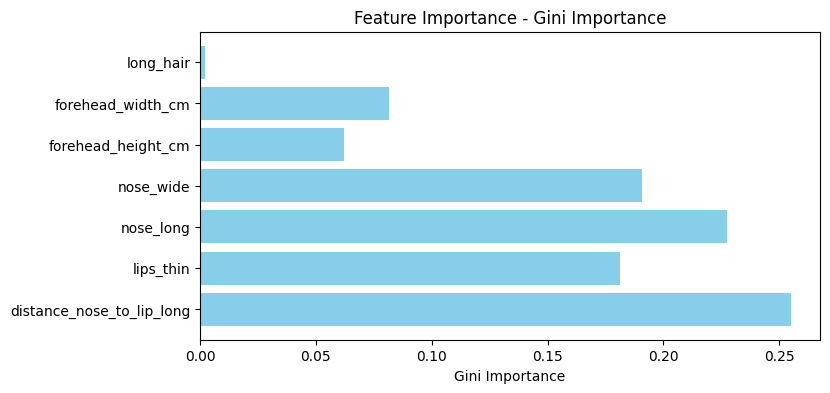

In [18]:
plt.figure(figsize=(8, 4))
plt.barh(x_train.columns, importances, color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()
plt.show()

In [19]:
x_train.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long'],
      dtype='object')

In [20]:
x_test.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long'],
      dtype='object')

In [21]:
print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (3500, 7)
Test: (1501, 7)


In [22]:
import shap

explainer = shap.Explainer(rf)
shap_values = explainer(x_train.reset_index().drop('index', axis =1))


In [23]:
x_train.reset_index().drop('index', axis =1)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
0,1,15.1,6.7,1,1,1,1
1,1,12.6,5.1,0,0,0,0
2,1,11.9,5.9,0,1,1,1
3,1,13.8,5.7,1,1,1,1
4,0,12.9,6.3,1,1,1,1
...,...,...,...,...,...,...,...
3495,1,13.0,6.5,0,0,0,0
3496,1,13.1,5.5,0,0,0,0
3497,1,12.0,5.9,0,0,0,0
3498,1,12.8,5.4,0,0,0,0


In [24]:
shap_values

.values =
array([[[-0.0005639 ,  0.0005639 ],
        [-0.11345971,  0.11345971],
        [-0.09299487,  0.09299487],
        ...,
        [-0.07729959,  0.07729959],
        [-0.06816672,  0.06816672],
        [-0.08525506,  0.08525506]],

       [[ 0.00193011, -0.00193011],
        [ 0.03159982, -0.03159982],
        [ 0.02109176, -0.02109176],
        ...,
        [ 0.12030932, -0.12030932],
        [ 0.09756963, -0.09756963],
        [ 0.11738261, -0.11738261]],

       [[-0.0020465 ,  0.0020465 ],
        [ 0.01005854, -0.01005854],
        [ 0.02448978, -0.02448978],
        ...,
        [-0.20296579,  0.20296579],
        [-0.19573598,  0.19573598],
        [-0.26059197,  0.26059197]],

       ...,

       [[ 0.000946  , -0.000946  ],
        [ 0.02755522, -0.02755522],
        [ 0.02551883, -0.02551883],
        ...,
        [ 0.11689506, -0.11689506],
        [ 0.08755839, -0.08755839],
        [ 0.12879884, -0.12879884]],

       [[ 0.00141417, -0.00141417],
        [ 0.03354

In [25]:
x_test.reset_index().drop('index', axis = 1).columns.to_list()

['long_hair',
 'forehead_width_cm',
 'forehead_height_cm',
 'nose_wide',
 'nose_long',
 'lips_thin',
 'distance_nose_to_lip_long']

For group "FEMALE"

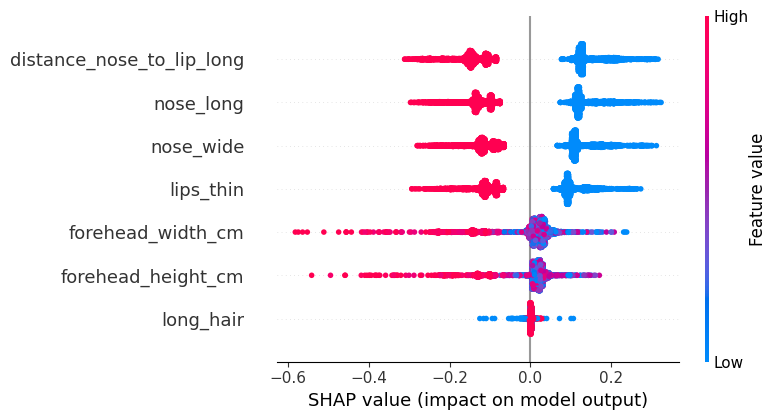

In [26]:
features = x_test.reset_index().drop('index', axis = 1).columns.to_list()
# Построение графика с модифицированными подписями
shap.summary_plot(shap_values.values[:,:,0], x_train, max_display=len(features))

For group "MALE"

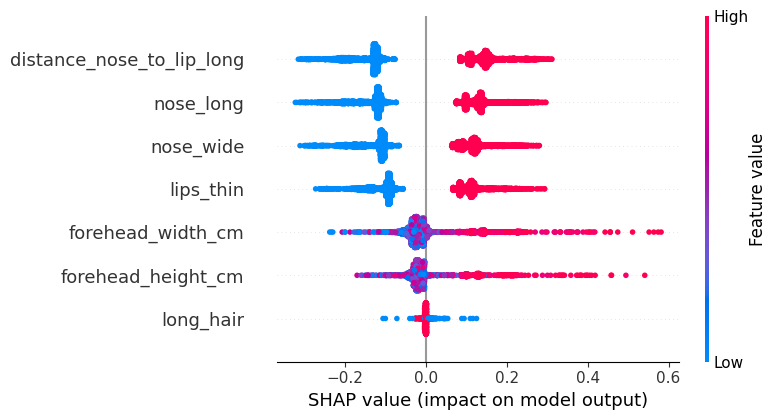

In [27]:
features = x_test.reset_index().drop('index', axis = 1).columns.to_list()
# Построение графика с модифицированными подписями
shap.summary_plot(shap_values.values[:,:,1], x_train, max_display=len(features))

In [28]:
from sklearn.decomposition import PCA

In [29]:
x_train

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
2115,1,15.1,6.7,1,1,1,1
4438,1,12.6,5.1,0,0,0,0
1146,1,11.9,5.9,0,1,1,1
2486,1,13.8,5.7,1,1,1,1
44,0,12.9,6.3,1,1,1,1
...,...,...,...,...,...,...,...
4426,1,13.0,6.5,0,0,0,0
466,1,13.1,5.5,0,0,0,0
3092,1,12.0,5.9,0,0,0,0
3772,1,12.8,5.4,0,0,0,0


In [30]:
sk_pca = PCA()
sk_X_transformed = sk_pca.fit_transform(x_train)

In [31]:
print(sk_X_transformed[:10:])

[[ 2.21805583e+00  3.16102362e-01  5.07186445e-01  1.22459731e-01
  -3.98407359e-02  1.40854045e-03  5.43674753e-02]
 [-9.89854091e-01 -8.58993099e-01 -5.58880628e-01  1.02324668e-01
  -1.12484528e-02  1.24312356e-02  7.92905393e-02]
 [-9.73955874e-01  9.45858564e-01 -2.19171463e-01  2.39074875e-01
   5.27447605e-01 -6.54934150e-01  2.84497745e-02]
 [ 9.44053055e-01  5.74698858e-01 -4.92142517e-01  1.07416578e-01
  -1.37974204e-02  1.34434270e-02  7.27256645e-02]
 [ 1.71213159e-01  1.09007164e+00  6.46656723e-02 -7.33314400e-01
   1.77022056e-01  2.91217763e-02 -4.30849124e-01]
 [-1.27309714e+00 -4.37572356e-01  3.90256936e-01  1.14459485e-01
  -3.35998277e-02 -3.79294364e-03  5.91471874e-02]
 [-1.47956913e+00 -4.37481688e-01  1.02879597e-01 -7.36611162e-01
   1.76597498e-01  2.73250255e-02 -4.25941552e-01]
 [ 2.29314317e+00 -1.03741359e-01 -7.36140181e-01  1.06137017e-01
  -1.00889950e-02  2.17114007e-02  8.02178022e-02]
 [-4.69430488e-02  1.06699335e+00 -3.32429842e-01  1.08098541e-0

In [32]:
print('sk explained_variance_ratio_', sk_pca.explained_variance_ratio_)

sk explained_variance_ratio_ [0.51211198 0.22132238 0.1000061  0.04496967 0.04142598 0.04073208
 0.0394318 ]


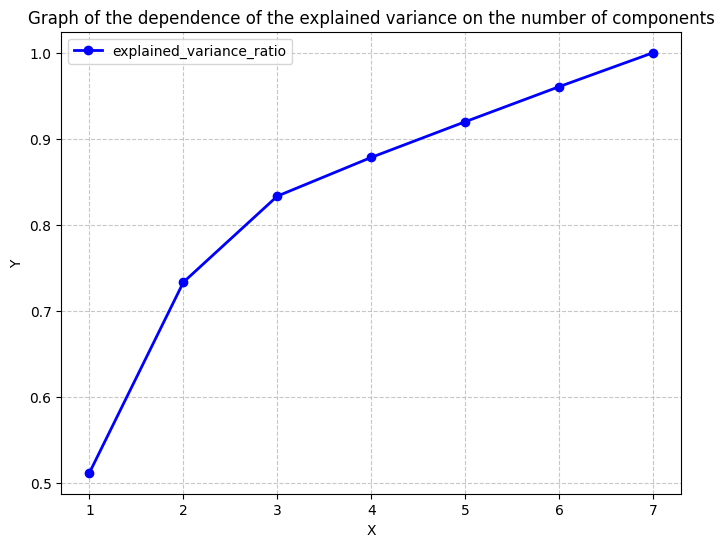

In [33]:
mas_of_y_pca = []
for i in range(len(sk_pca.explained_variance_ratio_)):
  mas_of_y_pca.append(sum(sk_pca.explained_variance_ratio_[0:i+1:]))
plt.figure(figsize=(8, 6))
plt.plot([i for i in range(1,8)], mas_of_y_pca,'o-', label='explained_variance_ratio', color='blue', linewidth=2)
plt.title('Graph of the dependence of the explained variance on the number of components')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [34]:
from sklearn.manifold import TSNE
sk_tsne = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=42)
X_embedded = sk_tsne.fit_transform(x_train)
X_embedded.shape

(3500, 2)

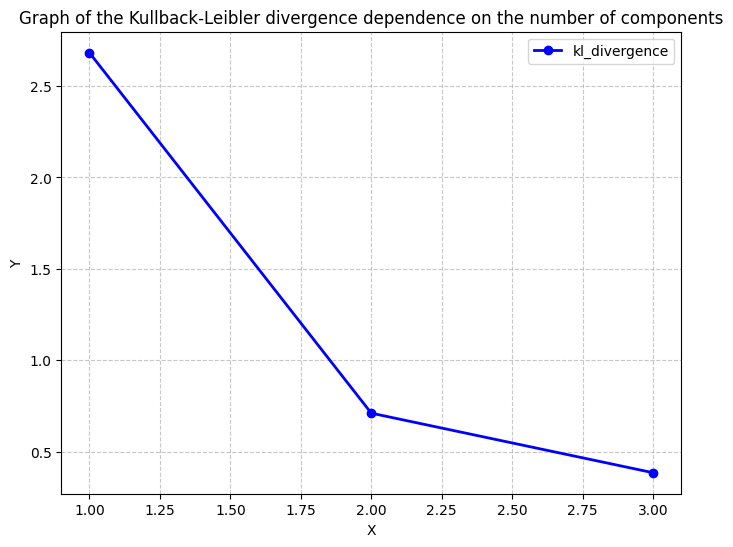

In [35]:
mas_of_y_tsne = []
for i in range(1, 4):
  sk_tsne = TSNE(n_components=i, learning_rate='auto', init='random', perplexity=3, random_state=42)
  X_embedded = sk_tsne.fit_transform(x_train)
  mas_of_y_tsne.append(sk_tsne.kl_divergence_)

plt.figure(figsize=(8, 6))
plt.plot([i for i in range(1,4)], mas_of_y_tsne,'o-', label='kl_divergence', color='blue', linewidth=2)
plt.title('Graph of the Kullback-Leibler divergence dependence on the number of components')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

KL-divergence is measured in bits, nats, or dits, but NOT as a percentage. This is an absolute measure of the "value" of information, not a relative percentage difference.

In [36]:
sk_tsne_n_2 = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=42)
X_embedded = sk_tsne_n_2.fit_transform(x_train)
X_embedded.shape

(3500, 2)

In [37]:
df_tsne = pd.DataFrame(X_embedded)
target_for_vis = y_train.reset_index().drop('index', axis = 1)
data_for_vis_tsne = pd.concat([df_tsne, target_for_vis], axis=1, join="inner")
data_for_vis_tsne

,0,1,gender
0,38.376625,20.457146,Male
1,-76.271477,-70.564056,Female
2,14.085572,26.882782,Male
3,67.866112,31.263382,Male
4,93.560341,18.784426,Male
...,...,...,...
3495,6.836747,-56.908630,Female
3496,-46.905109,-63.626385,Female
3497,-60.550934,48.744637,Female
3498,-40.238209,-58.732353,Female


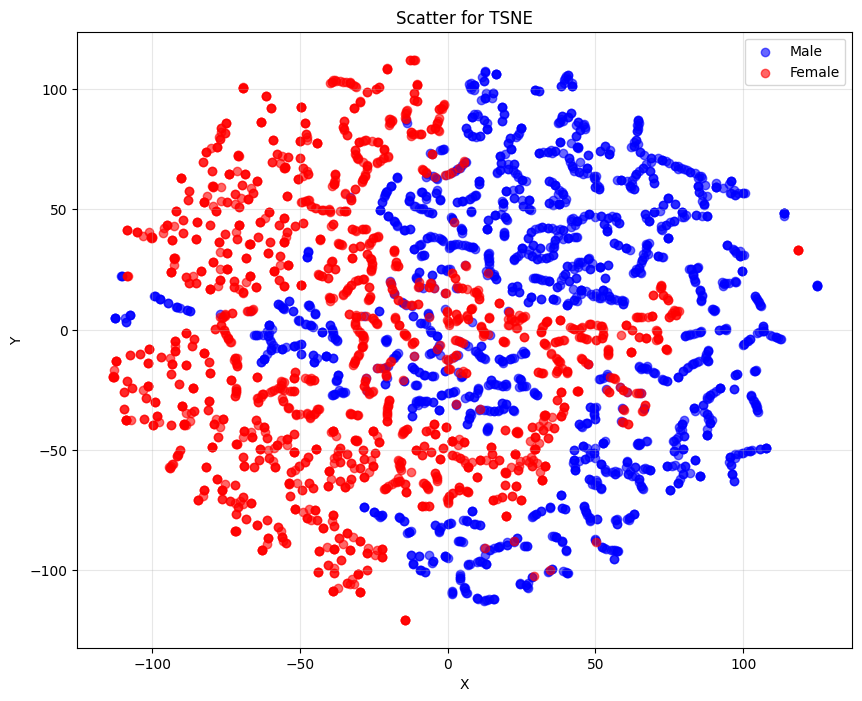

In [38]:

male_data = data_for_vis_tsne[data_for_vis_tsne['gender'] == 'Male']
female_data = data_for_vis_tsne[data_for_vis_tsne['gender'] == 'Female']

plt.figure(figsize=(10, 8))

plt.scatter(male_data[0], male_data[1],
           color='blue', alpha=0.6, label='Male')

plt.scatter(female_data[0], female_data[1],
           color='red', alpha=0.6, label='Female')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter for TSNE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [39]:
sk_pca_n_2 = PCA(n_components= 2)
df_pca = sk_pca_n_2.fit_transform(x_train)
df_pca = pd.DataFrame(df_pca)
data_for_vis_pca = pd.concat([df_pca, target_for_vis], axis=1, join="inner")

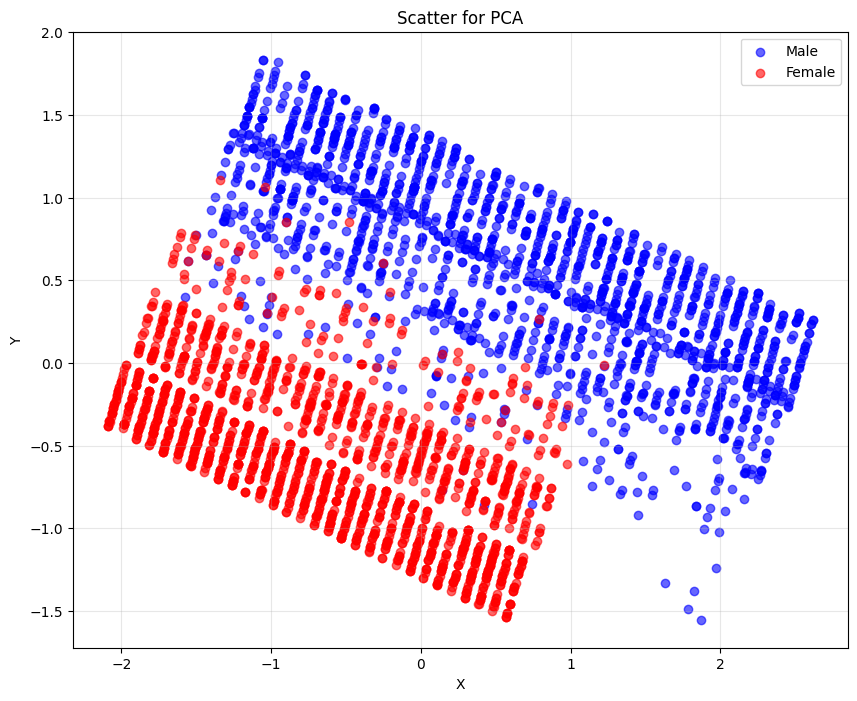

In [40]:
male_data = data_for_vis_pca[data_for_vis_pca['gender'] == 'Male']
female_data = data_for_vis_pca[data_for_vis_pca['gender'] == 'Female']

plt.figure(figsize=(10, 8))

plt.scatter(male_data[0], male_data[1],
           color='blue', alpha=0.6, label='Male')

plt.scatter(female_data[0], female_data[1],
           color='red', alpha=0.6, label='Female')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter for PCA')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

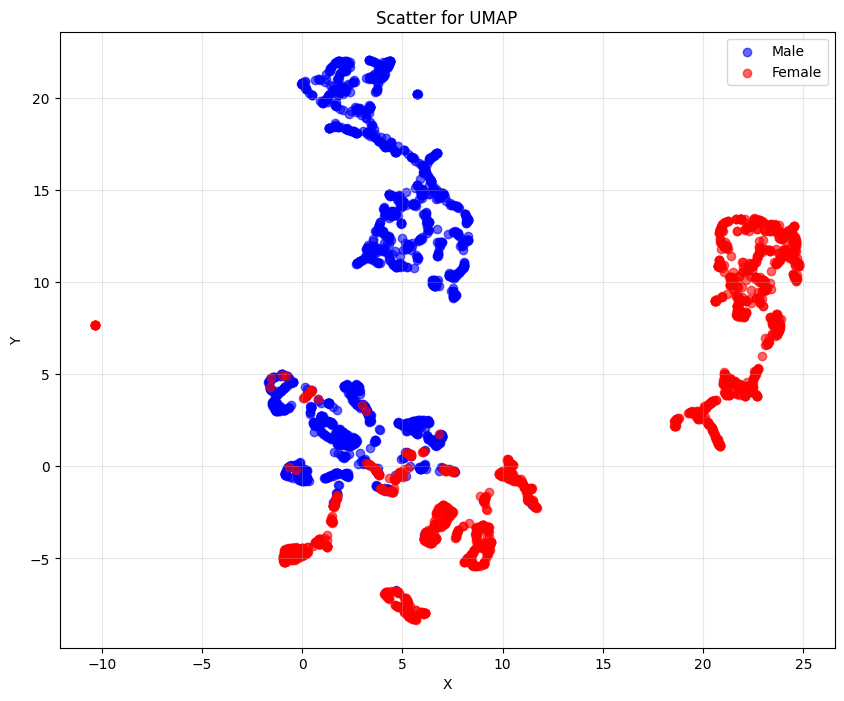

In [41]:
import umap
manifold = umap.UMAP().fit(x_train)
X_train_umap = manifold.transform(x_train)
X_train_umap = pd.DataFrame(X_train_umap)
data_for_vis_umap = pd.concat([X_train_umap, target_for_vis], axis=1, join="inner")
male_data = data_for_vis_umap[data_for_vis_umap['gender'] == 'Male']
female_data = data_for_vis_umap[data_for_vis_umap['gender'] == 'Female']

plt.figure(figsize=(10, 8))

plt.scatter(male_data[0], male_data[1],
           color='blue', alpha=0.6, label='Male')

plt.scatter(female_data[0], female_data[1],
           color='red', alpha=0.6, label='Female')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter for UMAP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
#https://archive.ics.uci.edu/dataset/222/bank+marketing
'''
age	Integer	Age
job	Categorical	Occupation	type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
marital	Categorical	Marital Status	marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
education	Categorical	Education Level	(categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
default	Binary		has credit in default?
balance	Integer		average yearly balance	euros
housing	Binary		has housing loan?
loan	Binary		has personal loan?
contact	Categorical		contact communication type (categorical: 'cellular','telephone')
day_of_week	Date		last contact day of the week
month	Date		last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
duration	Integer		last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
campaign	Integer		number of contacts performed during this campaign and for this client (numeric, includes last contact)
pdays	Integer		number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)
previous	Integer		number of contacts performed before this campaign and for this client
poutcome	Categorical		outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
y	Target	Binary		has the client subscribed a term deposit?
'''
#We don't need first 3 features

"\nage\tInteger\tAge\njob\tCategorical\tOccupation\ttype of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')\nmarital\tCategorical\tMarital Status\tmarital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)\neducation\tCategorical\tEducation Level\t(categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')\ndefault\tBinary\t\thas credit in default?\nbalance\tInteger\t\taverage yearly balance\teuros\nhousing\tBinary\t\thas housing loan?\nloan\tBinary\t\thas personal loan?\ncontact\tCategorical\t\tcontact communication type (categorical: 'cellular','telephone')\nday_of_week\tDate\t\tlast contact day of the week\nmonth\tDate\t\tlast contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')\nduration\tInteger\t\tlast contact duration, in

In [43]:
data_bank = pd.read_csv('bank.csv', sep= ';')
data_bank.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [44]:
data_bank.shape

(4119, 21)

In [45]:
mas_of_columns = []
for i in data_bank.columns:
  if data_bank[i].dtype == 'object' and i != 'y':
    mas_of_columns.append(i)

data_object = data_bank[mas_of_columns]
data_object = pd.get_dummies(data_object)
data_object = data_object.replace({True: 1, False: 0})
data_bank = data_bank.drop(mas_of_columns, axis = 1)
data_bank = pd.concat([data_bank, data_object], axis = 1, join = 'inner')
data_bank.shape

/tmp/ipython-input-1881484107.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_object = data_object.replace({True: 1, False: 0})


(4119, 64)

In [46]:
#Random forest
x_train_bank, x_test_bank, y_train_bank, y_test_bank = train_test_split(data_bank.drop(['y'], axis = 1) ,data_bank['y'], test_size=0.20, random_state=42)
rf_bank = RandomForestClassifier(n_estimators=100, random_state = 42)
rf_bank.fit(x_train_bank, y_train_bank)
rf_bank_predicts = rf_bank.predict(x_test_bank)
print(classification_report(y_test_bank, rf_bank_predicts))

              precision    recall  f1-score   support

          no       0.92      0.97      0.94       732
         yes       0.59      0.32      0.41        92

    accuracy                           0.90       824
   macro avg       0.76      0.64      0.68       824
weighted avg       0.88      0.90      0.89       824



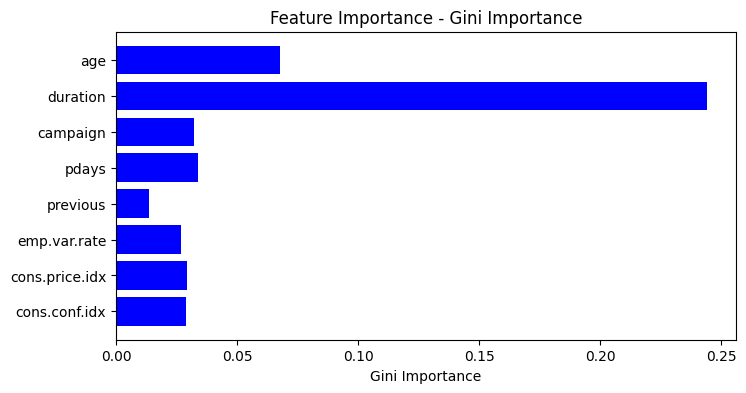

In [47]:
#feature importance
plt.figure(figsize=(8, 4))
plt.barh(x_train_bank.columns[:8:], rf_bank.feature_importances_[:8:], color='blue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()
plt.show()

In [48]:
#LIME
explainer_bank = lime.lime_tabular.LimeTabularExplainer(x_train_bank.values,feature_names = x_train_bank.columns,class_names=['NO','YES'])
predict_fn_rf_bank = lambda x: rf_bank.predict_proba(x).astype(float)
choosen_instance = x_test_bank.head(1).values[0]#можем выбрать любую запись
exp = explainer_bank.explain_instance(choosen_instance, predict_fn_rf_bank, num_features=10)
exp.show_in_notebook(show_all = False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


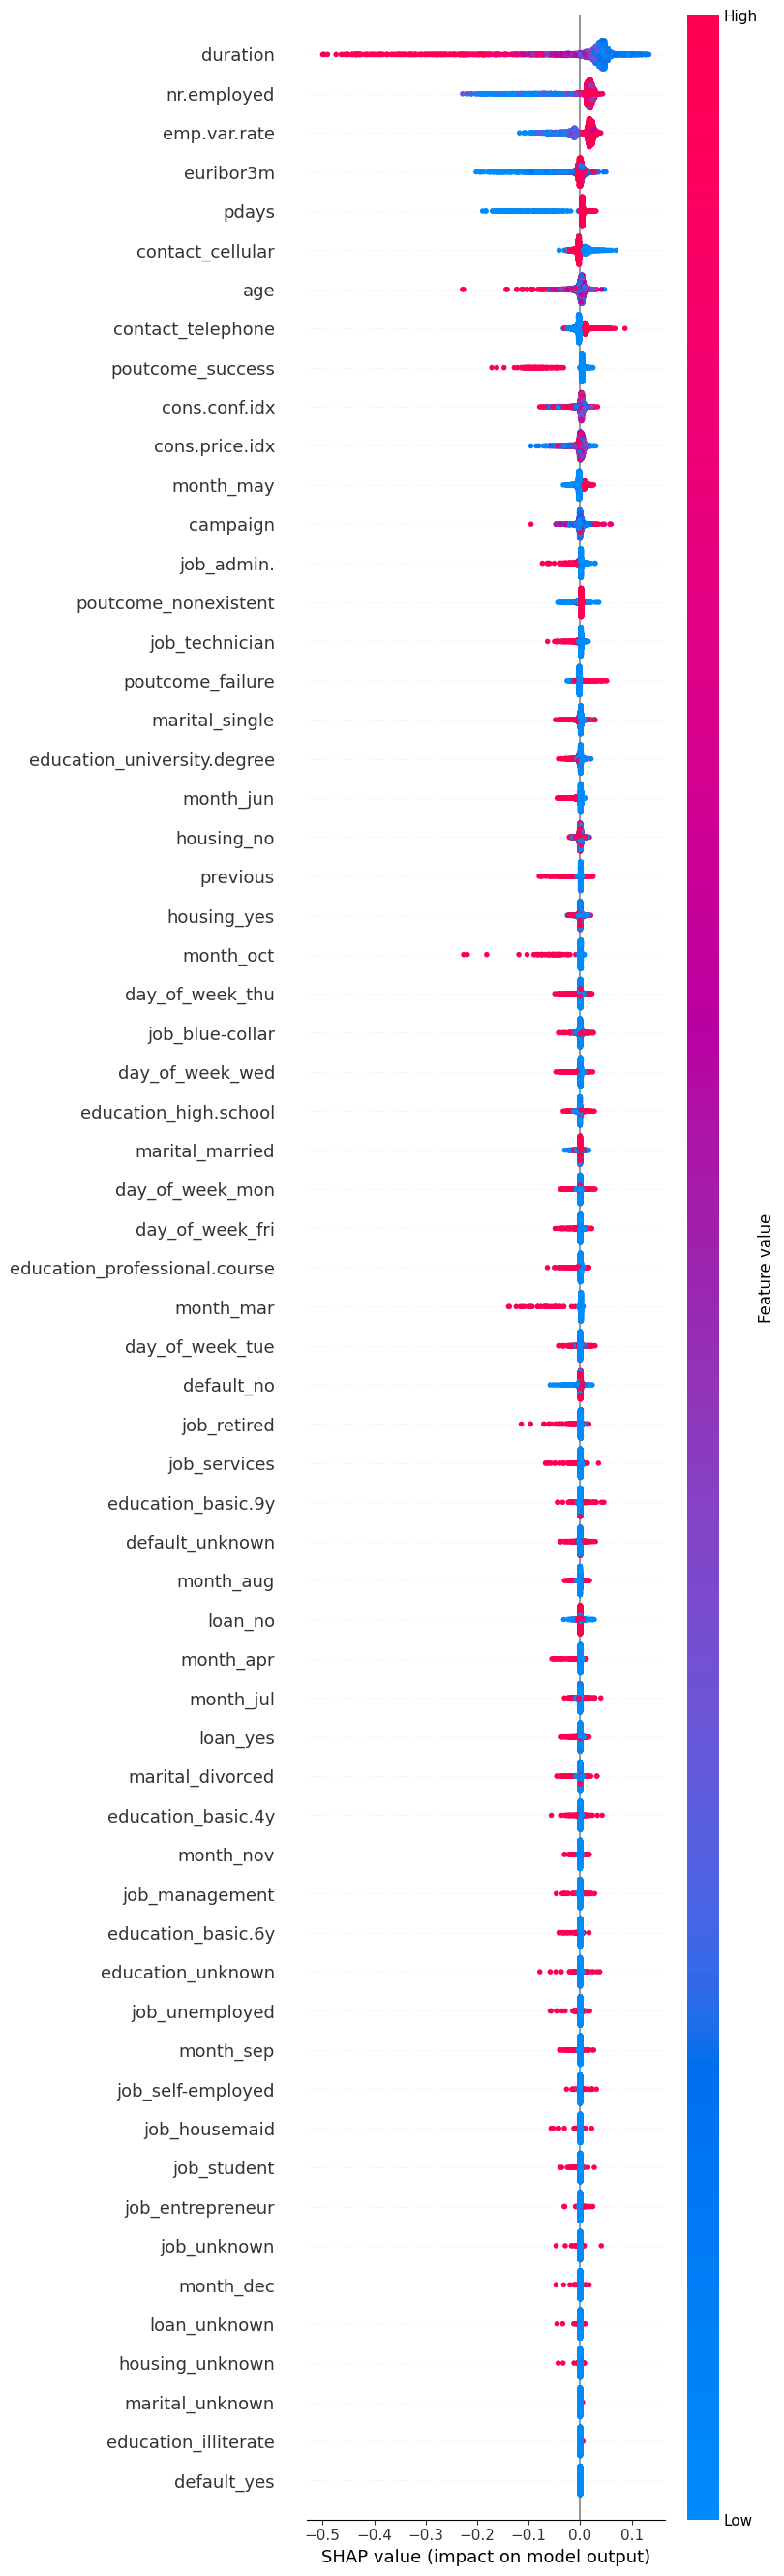

In [49]:
#SHAP
explainer_shap_bank = shap.Explainer(rf_bank)
shap_values_bank = explainer_shap_bank(x_train_bank.reset_index().drop('index', axis =1))
shap.summary_plot(shap_values_bank.values[:,:,0], x_train_bank, max_display=len(x_train_bank.reset_index().drop('index', axis = 1).columns.to_list()))

<Figure size 1000x800 with 0 Axes>

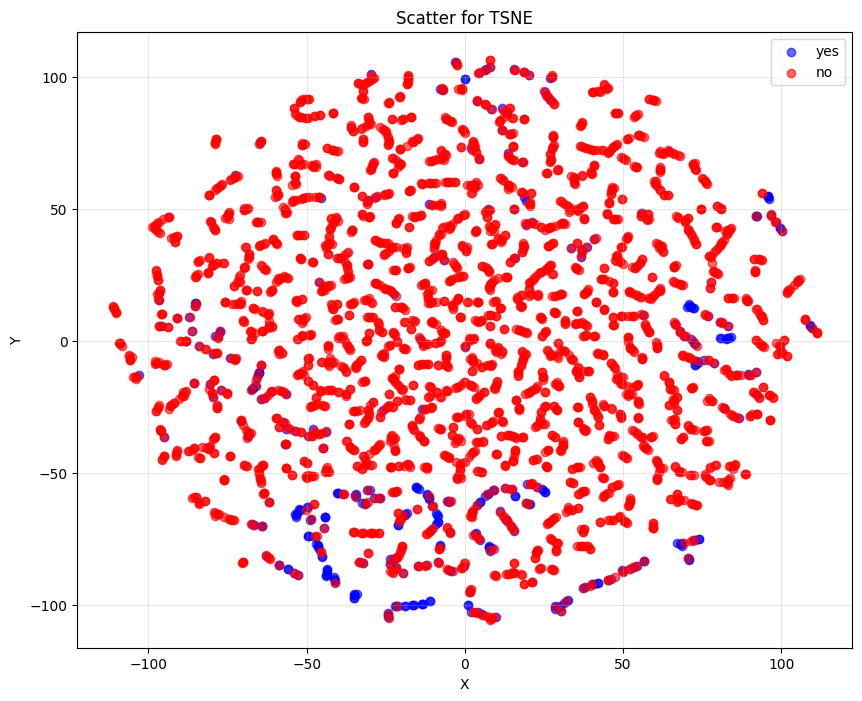

In [50]:
#TSNE
tsne_bank = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3, random_state=42)

X_embedded_bank = tsne_bank.fit_transform(x_train_bank)
df_tsne_bank = pd.DataFrame(X_embedded_bank)
data_bank_tsne = pd.concat([df_tsne_bank, y_train_bank.reset_index().drop('index', axis = 1)], axis=1, join="inner")

yes_data = data_bank_tsne[data_bank_tsne['y'] == 'yes']
no_data = data_bank_tsne[data_bank_tsne['y'] == 'no']

plt.figure(figsize=(10, 8))

plt.figure(figsize=(10, 8))

plt.scatter(yes_data[0], yes_data[1],
           color='blue', alpha=0.6, label='yes')

plt.scatter(no_data[0], no_data[1],
           color='red', alpha=0.6, label='no')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter for TSNE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

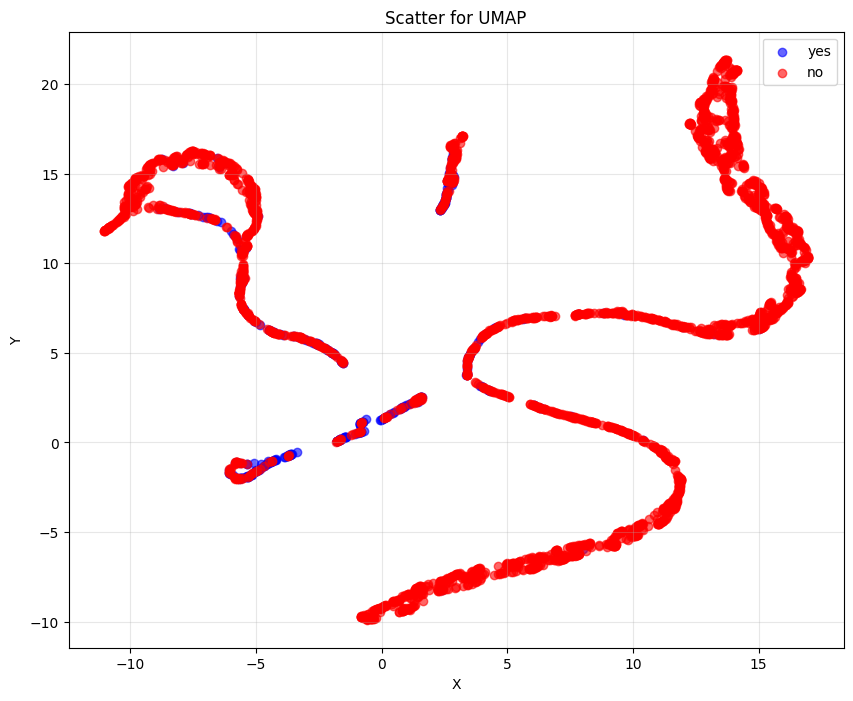

In [51]:
#UMAP
umap_bank = umap.UMAP()

X_embedded_bank = umap_bank.fit_transform(x_train_bank)
df_umap_bank = pd.DataFrame(X_embedded_bank)
data_bank_umap = pd.concat([df_umap_bank, y_train_bank.reset_index().drop('index', axis = 1)], axis=1, join="inner")

yes_data = data_bank_umap[data_bank_umap['y'] == 'yes']
no_data = data_bank_umap[data_bank_umap['y'] == 'no']

plt.figure(figsize=(10, 8))

plt.scatter(yes_data[0], yes_data[1],
           color='blue', alpha=0.6, label='yes')

plt.scatter(no_data[0], no_data[1],
           color='red', alpha=0.6, label='no')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter for UMAP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

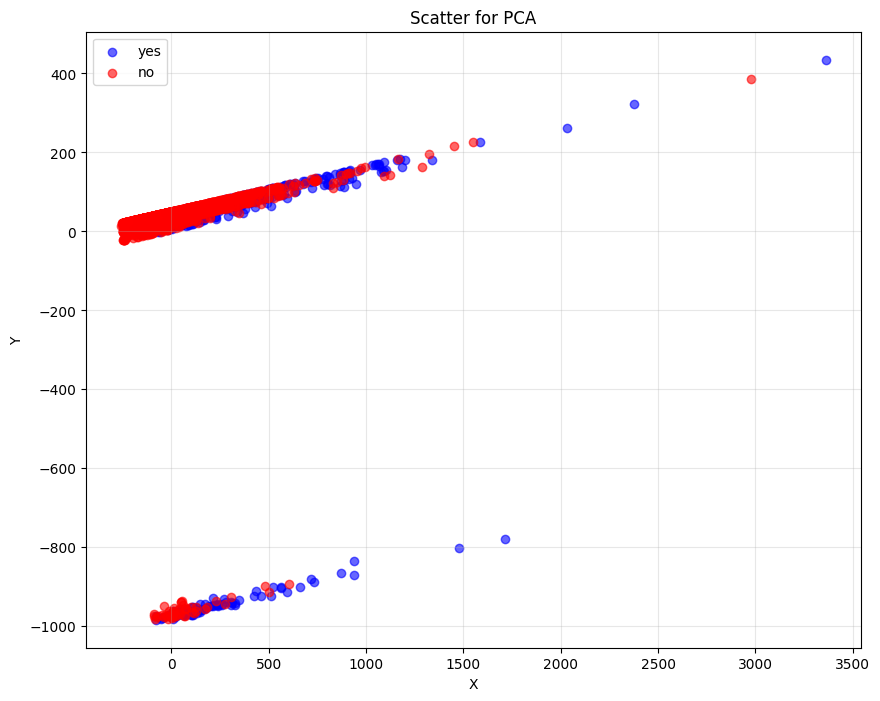

In [52]:
#PCA
pca_bank = PCA(n_components= 2)


X_embedded_bank = pca_bank.fit_transform(x_train_bank)
df_pca_bank = pd.DataFrame(X_embedded_bank)
data_bank_pca = pd.concat([df_pca_bank, y_train_bank.reset_index().drop('index', axis = 1)], axis=1, join="inner")

yes_data = data_bank_pca[data_bank_pca['y'] == 'yes']
no_data = data_bank_pca[data_bank_pca['y'] == 'no']

plt.figure(figsize=(10, 8))

plt.scatter(yes_data[0], yes_data[1],
           color='blue', alpha=0.6, label='yes')

plt.scatter(no_data[0], no_data[1],
           color='red', alpha=0.6, label='no')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter for PCA')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

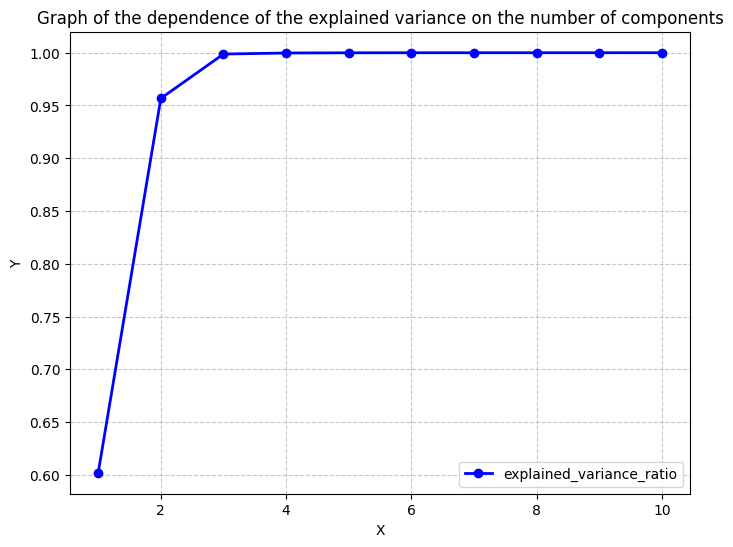

In [53]:
pca_bank_all_n = PCA()
X_transformed_bank = pca_bank_all_n.fit_transform(x_train_bank)
mas_of_y_pca = []
length = len(pca_bank_all_n.explained_variance_ratio_[:10:])
for i in range(length):
  mas_of_y_pca.append(sum(pca_bank_all_n.explained_variance_ratio_[0:i+1:]))
plt.figure(figsize=(8, 6))
plt.plot([i for i in range(1,length + 1)], mas_of_y_pca,'o-', label='explained_variance_ratio', color='blue', linewidth=2)
plt.title('Graph of the dependence of the explained variance on the number of components')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [54]:
pca_bank_all_n.explained_variance_ratio_

array([6.02117564e-01, 3.54598315e-01, 4.19937265e-02, 9.85841101e-04,
       1.90254785e-04, 5.48533528e-05, 9.59828400e-06, 4.53473130e-06,
       4.35221517e-06, 3.23759104e-06, 2.85817161e-06, 2.64474378e-06,
       2.60388808e-06, 2.53706199e-06, 2.35597544e-06, 2.10242012e-06,
       2.02615785e-06, 1.88050765e-06, 1.85065114e-06, 1.76734318e-06,
       1.68105842e-06, 1.35772257e-06, 1.26825676e-06, 1.20099107e-06,
       1.10342331e-06, 1.09157014e-06, 8.04666187e-07, 7.09993920e-07,
       6.94159592e-07, 6.33052335e-07, 6.08583439e-07, 4.82331043e-07,
       4.48887677e-07, 3.78885196e-07, 3.50875169e-07, 3.35747559e-07,
       2.99500374e-07, 2.91007502e-07, 2.54072991e-07, 2.22216601e-07,
       1.79494962e-07, 1.63109323e-07, 1.37531775e-07, 9.95718870e-08,
       8.49641876e-08, 7.14092083e-08, 4.70490540e-08, 4.41741421e-08,
       2.96305345e-08, 1.81467853e-08, 3.14440819e-09, 4.51796104e-20,
       8.23088460e-21, 7.92673781e-21, 3.90771179e-21, 9.41066616e-22,
      

In [56]:
pca_bank_new = PCA(n_components= 2)
x_train_bank_new = pca_bank_new.fit_transform(x_train_bank)
x_test_bank_new = pca_bank_new.transform(x_test_bank)
rf_bank_pca = RandomForestClassifier(n_estimators=100, random_state = 42)
rf_bank_pca.fit(x_train_bank_new, y_train_bank)
rf_bank_pca_predicts = rf_bank_pca.predict(x_test_bank_new)
print('new rf(with PCA and n = 2)')
print(classification_report(y_test_bank, rf_bank_pca_predicts))
print('------------------------------')
print('old rf(without PCA)')
print(classification_report(y_test_bank, rf_bank_predicts))

new rf(with PCA and n = 2)
              precision    recall  f1-score   support

          no       0.93      0.93      0.93       732
         yes       0.43      0.41      0.42        92

    accuracy                           0.87       824
   macro avg       0.68      0.67      0.67       824
weighted avg       0.87      0.87      0.87       824

------------------------------
old rf(without PCA)
              precision    recall  f1-score   support

          no       0.92      0.97      0.94       732
         yes       0.59      0.32      0.41        92

    accuracy                           0.90       824
   macro avg       0.76      0.64      0.68       824
weighted avg       0.88      0.90      0.89       824

